In [1]:
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo
import numpy as np
import pandas as pd
  
# fetch dataset 
statlog_australian_credit_approval = fetch_ucirepo(id=143) 
  
# data (as pandas dataframes) 
X = statlog_australian_credit_approval.data.features 
y = statlog_australian_credit_approval.data.targets 
  
# metadata 
print(statlog_australian_credit_approval.metadata) 
  
# variable information 
print(statlog_australian_credit_approval.variables) 

{'uci_id': 143, 'name': 'Statlog (Australian Credit Approval)', 'repository_url': 'https://archive.ics.uci.edu/dataset/143/statlog+australian+credit+approval', 'data_url': 'https://archive.ics.uci.edu/static/public/143/data.csv', 'abstract': 'This file concerns credit card applications. This database exists elsewhere in the repository (Credit Screening Database) in a slightly different form', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 690, 'num_features': 14, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': [], 'target_col': ['A15'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1987, 'last_updated': None, 'dataset_doi': '10.24432/C59012', 'creators': ['Ross Quinlan'], 'intro_paper': None, 'additional_info': {'summary': 'This file concerns credit card applications.  All attribute names and values have been changed to meaningless symbols to protect 

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
random_state = 42

data_path = "./data/australian.dat"

credit = np.genfromtxt(data_path)
credit = pd.DataFrame(credit)
credit.columns = [f'X{i}' for i in range(1, 15)] + ['Y']
print(credit.head())

X = credit.iloc[:, :-1].values
y = credit.iloc[:, -1].values

encode_rules = ColumnTransformer(
    transformers = [('encoder', OneHotEncoder(categories='auto'), [3, 4, 5, 11])],
    remainder = 'passthrough'
)

X = encode_rules.fit_transform(X)

    X1     X2     X3   X4   X5   X6     X7   X8   X9   X10  X11  X12    X13  \
0  1.0  22.08  11.46  2.0  4.0  4.0  1.585  0.0  0.0   0.0  1.0  2.0  100.0   
1  0.0  22.67   7.00  2.0  8.0  4.0  0.165  0.0  0.0   0.0  0.0  2.0  160.0   
2  0.0  29.58   1.75  1.0  4.0  4.0  1.250  0.0  0.0   0.0  1.0  2.0  280.0   
3  0.0  21.67  11.50  1.0  5.0  3.0  0.000  1.0  1.0  11.0  1.0  2.0    0.0   
4  1.0  20.17   8.17  2.0  6.0  4.0  1.960  1.0  1.0  14.0  0.0  2.0   60.0   

      X14    Y  
0  1213.0  0.0  
1     1.0  0.0  
2     1.0  0.0  
3     1.0  1.0  
4   159.0  1.0  


In [4]:
from sklearn.base import BaseEstimator, ClassifierMixin

class DecisionTree(BaseEstimator, ClassifierMixin):
    def __init__(self, max_depth=None, min_samples_split=2):
        self.children = None
        self.feature_index = None
        self.threshold = None
        self.value = None
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split

    def calculate_entropy(self, y):
        _, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        ans = 0.0
        for p in probs:
            if p > 0:
                ans += p * np.log2(p)
        return -ans

    def _build_tree(self, X, y, depth):
        node = DecisionTree(self.max_depth, self.min_samples_split)
        node.n_features = self.n_features

        # Leaf: max depth reached, too few samples, or pure node
        if depth == self.max_depth or len(y) < self.min_samples_split or len(np.unique(y)) == 1:
            node.value = int(np.argmax(np.bincount(y.astype(int))))
            return node

        best_gain = -1
        best_feature_index = None
        best_threshold = None
        best_left_indices = None
        best_right_indices = None

        for feature_index in range(self.n_features):
            thresholds = np.unique(X[:, feature_index])
            for threshold in thresholds:
                left_indices = np.where(X[:, feature_index] <= threshold)[0]
                right_indices = np.where(X[:, feature_index] > threshold)[0]

                if len(left_indices) == 0 or len(right_indices) == 0:
                    continue

                gain = (self.calculate_entropy(y)
                        - (len(left_indices) / len(y)) * self.calculate_entropy(y[left_indices])
                        - (len(right_indices) / len(y)) * self.calculate_entropy(y[right_indices]))

                if gain > best_gain:
                    best_gain = gain
                    best_feature_index = feature_index
                    best_threshold = threshold
                    best_left_indices = left_indices
                    best_right_indices = right_indices

        # No useful split found → leaf
        if best_gain <= 0 or best_feature_index is None:
            node.value = int(np.argmax(np.bincount(y.astype(int))))
            return node

        node.feature_index = best_feature_index
        node.threshold = best_threshold
        node.children = [
            self._build_tree(X[best_left_indices], y[best_left_indices], depth + 1),
            self._build_tree(X[best_right_indices], y[best_right_indices], depth + 1)
        ]
        return node

    def fit(self, X, y):
        self.n_samples, self.n_features = X.shape
        self.n_classes = len(set(y))
        root = self._build_tree(X, y, 0)
        self.feature_index = root.feature_index
        self.threshold = root.threshold
        self.children = root.children
        self.value = root.value
        return self

    def predict(self, X):
        y = []
        for i in range(len(X)):
            node = self
            while node.children is not None:
                if X[i, node.feature_index] <= node.threshold:
                    node = node.children[0]
                else:
                    node = node.children[1]
            y.append(node.value)
        return np.array(y)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

print(X_train.shape, X_test.shape)


(552, 38) (138, 38)


In [5]:
model = DecisionTree(max_depth = 6, min_samples_split = 2)
model.fit(X, y)
y_pred = model.predict(X_test)

precision = np.sum((y_pred == 1) & (y_test == 1)) / np.sum(y_pred == 1)
recall = np.sum((y_pred == 1) & (y_test == 1)) / np.sum(y_test == 1)
f1_score = 2 * (precision * recall) / (precision + recall)

print("Precision: ", precision)
print("Recall: ", recall)
print("F1 Score: ", f1_score)

Precision:  0.9555555555555556
Recall:  0.8431372549019608
F1 Score:  0.8958333333333333


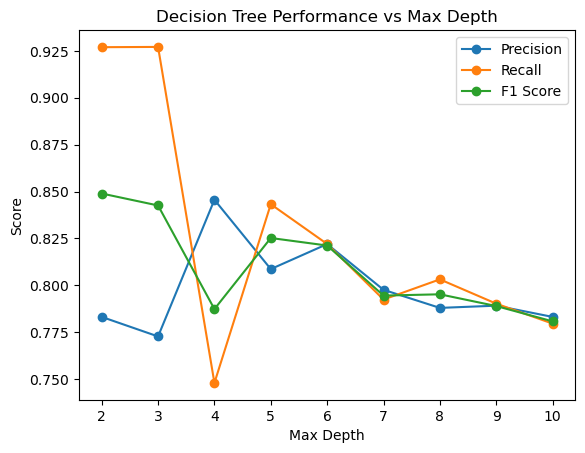

In [6]:
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=random_state)

mean_precisions, mean_recalls, mean_f1_scores = [], [], []
depth_range = range(2, 11)

for max_depth in depth_range:
    precisions, recalls, f1_scores = [], [], []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        clf = DecisionTree(max_depth=max_depth, min_samples_split=2)
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_val)

        p = np.sum((y_pred == 1) & (y_val == 1)) / np.sum(y_pred == 1)
        r = np.sum((y_pred == 1) & (y_val == 1)) / np.sum(y_val == 1)
        f = 2 * (p * r) / (p + r) if (p + r) > 0 else 0.0

        precisions.append(p)
        recalls.append(r)
        f1_scores.append(f)

    mean_precisions.append(np.mean(precisions))
    mean_recalls.append(np.mean(recalls))
    mean_f1_scores.append(np.mean(f1_scores))

plt.plot(list(depth_range), mean_precisions, marker='o', label='Precision')
plt.plot(list(depth_range), mean_recalls, marker='o', label='Recall')
plt.plot(list(depth_range), mean_f1_scores, marker='o', label='F1 Score')

plt.legend()
plt.xlabel('Max Depth')
plt.ylabel('Score')
plt.title('Decision Tree Performance vs Max Depth')
plt.show()


In [7]:
from sklearn.model_selection import GridSearchCV

parameters = {
    'max_depth': [5, 6, 7, 8],
    'min_samples_split': [2, 5, 10],
}

grid = GridSearchCV(estimator=DecisionTree(), param_grid=parameters, scoring='f1', cv=5)
grid.fit(X, y)
print("Best Parameters: ", grid.best_params_)
print("Best F1 Score: ", grid.best_score_)
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
precision = np.sum((y_pred == 1) & (y_test == 1)) / np.sum(y_pred == 1)
recall = np.sum((y_pred == 1) & (y_test == 1)) / np.sum(y_test == 1)
f1_score = 2 * (precision * recall) / (precision + recall)
print("Precision: ", precision)
print("Recall: ", recall)
print("F1 Score: ", f1_score)


Best Parameters:  {'max_depth': 6, 'min_samples_split': 10}
Best F1 Score:  0.7932623934139403
Precision:  0.9545454545454546
Recall:  0.8235294117647058
F1 Score:  0.8842105263157896


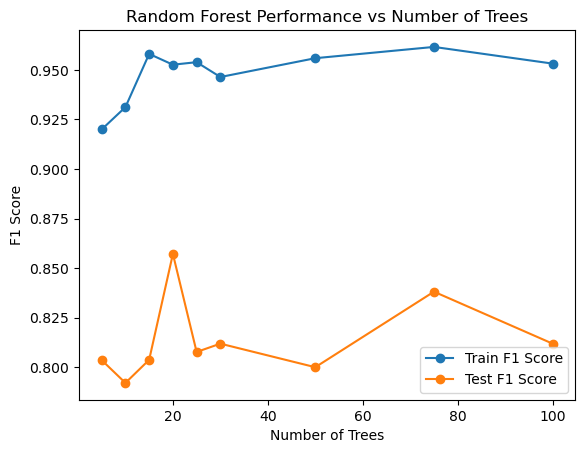

In [8]:
class RandomForest:
    def __init__(self, n_estimators=100, max_depth=None, min_samples_split=2):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []

    def fit(self, X, y):
        for _ in range(self.n_estimators):
            indices = np.random.choice(len(X), len(X), replace=True)
            X_sample, y_sample = X[indices], y[indices]
            tree = DecisionTree(max_depth=self.max_depth, min_samples_split=self.min_samples_split)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X):
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        return np.round(np.mean(tree_preds, axis=0)).astype(int)
    
num_trees = [5, 10, 15, 20, 25, 30, 50, 75, 100]
train_scores, test_scores = [], []

for ntress in num_trees:
    rf = RandomForest(n_estimators=ntress, max_depth=6, min_samples_split=2)
    rf.fit(X_train, y_train)
    
    train_pred = rf.predict(X_train)
    test_pred = rf.predict(X_test)
    
    train_precision = np.sum((train_pred == 1) & (y_train == 1)) / np.sum(train_pred == 1)
    train_recall = np.sum((train_pred == 1) & (y_train == 1)) / np.sum(y_train == 1)
    train_f1_score = 2 * (train_precision * train_recall) / (train_precision + train_recall) if (train_precision + train_recall) > 0 else 0.0
    
    test_precision = np.sum((test_pred == 1) & (y_test == 1)) / np.sum(test_pred == 1)
    test_recall = np.sum((test_pred == 1) & (y_test == 1)) / np.sum(y_test == 1)
    test_f1_score = 2 * (test_precision * test_recall) / (test_precision + test_recall) if (test_precision + test_recall) > 0 else 0.0
    
    train_scores.append(train_f1_score)
    test_scores.append(test_f1_score)

plt.plot(num_trees, train_scores, marker = 'o', label = 'Train F1 Score')
plt.plot(num_trees, test_scores, marker = 'o', label = 'Test F1 Score')
plt.xlabel('Number of Trees')
plt.ylabel('F1 Score')
plt.title('Random Forest Performance vs Number of Trees')
plt.legend()
plt.show()